# riverWQ Modelling — Predicting E. coli Contamination in NZ Rivers

This notebook builds and evaluates regression and classification models to predict E. coli contamination from catchment-level features. All preprocessing and modelling decisions are based on '01_eda.pynb'.

# 1. Setup & Data Preparation

## 1.1 Library imports

**The libraries that will be used are imported in the cell below.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
# Data split tool
from sklearn.model_selection import train_test_split
# LogisticRegression method tool
from sklearn.linear_model import LinearRegression, LogisticRegression
# KNN model method tool
from sklearn.neighbors import KNeighborsClassifier
# Random Forest method tool
from sklearn.ensemble import RandomForestClassifier
# Classification report tool
from sklearn.metrics import classification_report
# Confusion metrix tool
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score, accuracy_score, f1_score, classification_report
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import StratifiedKFold
from sklearn.neural_network import MLPRegressor, MLPClassifier
import joblib

## 1.2 Dataset Loading

In [2]:
# Load the dataset and show
df = pd.read_csv('../data/riverWQ_dataset.csv')
df.shape

(396, 38)

# 2. Data Preprocessing

This section will prepare the dataset for modelling. Firstly, the rows with missing target values will be removed. And the input features will be organised into numerical and categorical groups so they can be transformaed appropriately. And the data will be split into training and test sets. A preprocessing pipeline will be built then.

## 2.1 Clean the dataset

In this section, the missing rows of the targets will be dropped. And the duplicate column 'pct_cropland' observed in the EDA will be dropped.

In [3]:
# Drop rows with missing E. coli targets and reset the index
df = df.dropna(subset=['ecoli_median', 'ecoli_band']).reset_index(drop=True)
df.shape

(339, 38)

In [4]:
# Drop duplicate land cover column
df = df.drop(columns=['pct_cropland'])
df.shape

(339, 37)

## 2.2 Define feature sets

In this section, features will be organised into different groups(numerical and categorical). Broad-level pct columns are excluded because they are exact sums of their medium-level sub-categories. Including both levels would introduce multicollinearity.

**Numerical features**: 11 medium-level land cover percentages and 'mean_annual_rainfall_mm'.

**Categorical features**: 'wfs_altitude' and 'rec_land_cover_type'.

In [5]:
numerical_features = [
    'pct_cropping_horticulture',
    'pct_indigenous_forest',
    'pct_exotic_forest',
    'pct_exotic_grassland',
    'pct_tussock_grassland',
    'pct_other_herbaceous_vegetation',
    'pct_indigenous_scrub_shrubland',
    'pct_exotic_scrub_shrubland',
    'pct_urban_area',
    'pct_natural_bare_lightly-vegetated_surfaces',
    'pct_artificial_bare_surfaces',
    'mean_annual_rainfall_mm',
]

categorical_features = [
    'wfs_altitude',
    'rec_land_cover_type',
]

feature_columns = numerical_features + categorical_features


## 2.3 Train/test split

In this section, data will be split into training and test sets before any preprocessing is fitted.

An 80/20 split will be used. And the same split is used for both regression and classfication tasks so the two models are evaluated on the same sites.

**The data will be split in the following cell.*

In [6]:
# Use .copy to avoid warning on Pandas
X = df[feature_columns].copy()
y_reg = df['ecoli_median'].copy()
y_clf = df['ecoli_band'].copy()
# Split the data and use stratify to avoid random imbalance
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf,
    test_size=0.2,
    stratify=y_clf,
    random_state=42,
)

## 2.4 Build preprocessing pipeline

In this section, a 'ColumnTransformer' will be built to each feature group. Numerical features will be standardised and categorical features are one-hot encoded. The transformer will be wrapped in a 'Pipeline' together with each model later.

**The preprocessor will be built in the following cell.**

In [7]:
# Use ColumnTransformer to deal with standardscaler and onehot simultaneously.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features),
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

The preprocessor is ready to go.

# 3. Evaluation Metrics

In this section, evaluation metrics will be selected and justified for each task before building the models.


## Regression metrics

Three metrics for regression and classification will be reported as follows:

**RMSE** 
It penalises large errors more heavily. EDA shows that 'ecoli_mean' is heavily right-skewed with a long tail. Since it is a freshwater management dataset and task, misclassifying a band E site as clean would prevent it from being flagged as intervention. RMSE makes such errors invisible and help with more effective decisions.

**MAE**
It gives the typical absolute error. And MAE treats all the error equally, having MAE alongside RMSE shows whether RMSE is being driven by a small number of misses or noises.

**R²**
It is the proportion of variance in 'ecoli_median' explained by the catchment fatures. EDA found that even the strongest feature only reach Spearman around 0.5, which suggests that these data is useful but not quite signal. R² calculates how much the combined feature set captures that means how much of E. coli variation catchment characteristics alone can explain.

## Classification metrics

**Macro-F1**
It averages F1 across the five bands with equal weight. EDA showed that bands B and C have fewer samples that a classifier would tend to sacrifice for accuracy. But Macro-F1 treats them equally.

**Precision, recall and F1 based on per-class**
EDA showed that feature separation is obvious for band E but weak between A-D. And per-class metrics show the statistics directly.

**Confusion matrix**
The dataset is about water contamination. Thus, misclassifying A with B might not affect greatly but confusing A with E will be a serious one. Confusion matrix is the only way to see which kinds of mistakes the model is making and in EDA, it is reported that errors will likely be concentrated in the middle bands.

**Accuracy**
It is used for reference since it is the most familiar metrics while it will not be used for model selections.

- A 'DummyClassifier' is also reported as a baseline. Because the majority bands are so large, the dummy will work as a reference and comparison.

# 4. Regression Modelling

This section builds and tunes three regression models to predict 'ecoli_median' alongside a 'DummyRegressor' baseline. Each model is built as a pipeline combining the preprocessor with the model and wrapped in 'TransformedTargetRegressor' to apply log1p to the target during training. 

Hyperparameters are tuned via 5-fold cross-validation on the training set, and the three models are compared on their CV scores to select the final regression model. 

## 4.1 Dummy baseline

Establish a 'DummyRegressor' baseline with 'mean', which always predicts the training mean of 'ecoli_median'.

The dummy is evaluated using 5-fold cross-validation on the training set, with the same metric(RMSE) used to compare the other models.

In [8]:
# Build the dummy 
dummy_reg = DummyRegressor(strategy='mean')

# 5-fold CV
cv_scores = cross_val_score(
    dummy_reg,
    X_train,
    y_reg_train,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='neg_root_mean_squared_error'
)

# Convert to positive numbers while getting the mean
dummy_cv_rmse = -cv_scores.mean()
dummy_cv_rmse_std = cv_scores.std()

print(f"Dummy CV RMSE: {dummy_cv_rmse:.1f} ± {dummy_cv_rmse_std:.1f} MPN/100mL")



Dummy CV RMSE: 381.7 ± 104.3 MPN/100mL


The output of the dummy baseline is above. And the trained models in 4.2-4.4 should outperform this baseline, or the catchment-level features carry no useful signal for the regression task then.

## 4.2 Linear Regression

Linear Regression has no regularisation hyperparameters to tune in its plain form. The model is wrapped in TransformedTargetRegressor so the log transformation of 'ecoli_median' identified in EDA(skewness≈3.05) is applied during training, and with predictions returned on the original scale.

CV RMSE on the training set is reported with the same 5-fold scheme used for the dummy, so the two are directly comparable. And which is also for checking under or over fitting.

In [9]:
# Build the pipeline with preprocessor and LR
lr_pipe = Pipeline([
    ('pre', preprocessor),
    ('model', LinearRegression())  
])
# Wrap the pipeline with log transformation
lr_reg = TransformedTargetRegressor(
    regressor=lr_pipe,
    func=np.log1p, # Transform before training
    inverse_func=np.expm1 # Return after training
)
# 5-fold CV
cv_scores = cross_val_score(
    lr_reg,
    X_train,
    y_reg_train,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring= 'neg_root_mean_squared_error'
)
# Calculate and reverse on CV
lr_cv_rmse = -cv_scores.mean()
lr_cv_rmse_std = cv_scores.std()
# Calculate trained RMSE
lr_reg.fit(X_train, y_reg_train)
lr_train_pred = lr_reg.predict(X_train)
lr_train_rmse = root_mean_squared_error(y_reg_train, lr_train_pred)

print(f"Linear Regression CV RMSE:    {lr_cv_rmse:.1f} ± {lr_cv_rmse_std:.1f} MPN/100mL")
print(f"Linear Regression Train RMSE: {lr_train_rmse:.1f} MPN/100mL")

Linear Regression CV RMSE:    436.2 ± 172.8 MPN/100mL
Linear Regression Train RMSE: 322.3 MPN/100mL


The CV RMSE(436±172.8) is higher than the Train RMSE(322), which means the model performs better on the training set. The large STD also shows that performance varies a lot depending on which sites are held out. It suggests that the result is driven by a few extreme high 'ecoli_median' sites. The comprehensive comparison will be conducted after all the models are trained.

## 4.3 Random Forest Regressor

Random Forest is an ensemble of decision trees that can capture non-linear patterns. The same log transformation will be applied although the random faorest model is not very sensitive to input data, while learning the traning set, massive 'y' will confuse the learning.

Three key hyperparameters are tuned with 5-fold cross-validation:

- 'n_estimators': number of trees in the forest
- 'max_depth': maximum depth of each tree (controls model capacity)
- 'min_samples_leaf': minimum samples required at a leaf (controls overfitting)

In [10]:
# Build pipeline: preprocessing + random forest
rf_pipe = Pipeline([
    ('pre', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])
# Wrap with log transformation
rf_reg = TransformedTargetRegressor(
    regressor=rf_pipe,
    func=np.log1p,
    inverse_func=np.expm1
)
# Hyperparameter grid
param_grid = {
    'regressor__model__n_estimators': [100, 300, 500], # The first hyperparameter to be tuned
    'regressor__model__max_depth': [5, 10, 20, None],
    'regressor__model__min_samples_leaf': [1, 2, 5],
}
# GridSearchCV with 5-fold CV
rf_grid = GridSearchCV(
    rf_reg,
    param_grid=param_grid,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='neg_root_mean_squared_error',
    return_train_score=True # Return the training score for visualisation
)
# Train the 5-fold CV mmodel
rf_grid.fit(X_train, y_reg_train)
# Grab the best result
rf_cv_rmse = -rf_grid.best_score_
rf_best_params = rf_grid.best_params_
# Train the model with the best combo
rf_train_pred = rf_grid.best_estimator_.predict(X_train)
rf_train_rmse = root_mean_squared_error(y_reg_train, rf_train_pred)

print(f"Best params: {rf_best_params}")
print(f"Random Forest CV RMSE:    {rf_cv_rmse:.1f} MPN/100mL")
print(f"Random Forest Train RMSE: {rf_train_rmse:.1f} MPN/100mL")


Best params: {'regressor__model__max_depth': 10, 'regressor__model__min_samples_leaf': 5, 'regressor__model__n_estimators': 500}
Random Forest CV RMSE:    338.1 MPN/100mL
Random Forest Train RMSE: 309.7 MPN/100mL


The best configuration is 'max_depth=10', 'min_samples_leaf=5', 'n_estimators=500', with CV RMSE 338 and Train RMSE 310. The CV-Train gap is small (~9%), so the model is neither under- nor over-fitting. 
CV RMSE is about 22% lower than Linear Regression, confirming that the non-linear threshold-like patterns in EDA Section   4.1 are better captured by trees.

**In the next code cell, the visualisation will be drawn to show how CV RMSE changes across each hyperparameter**

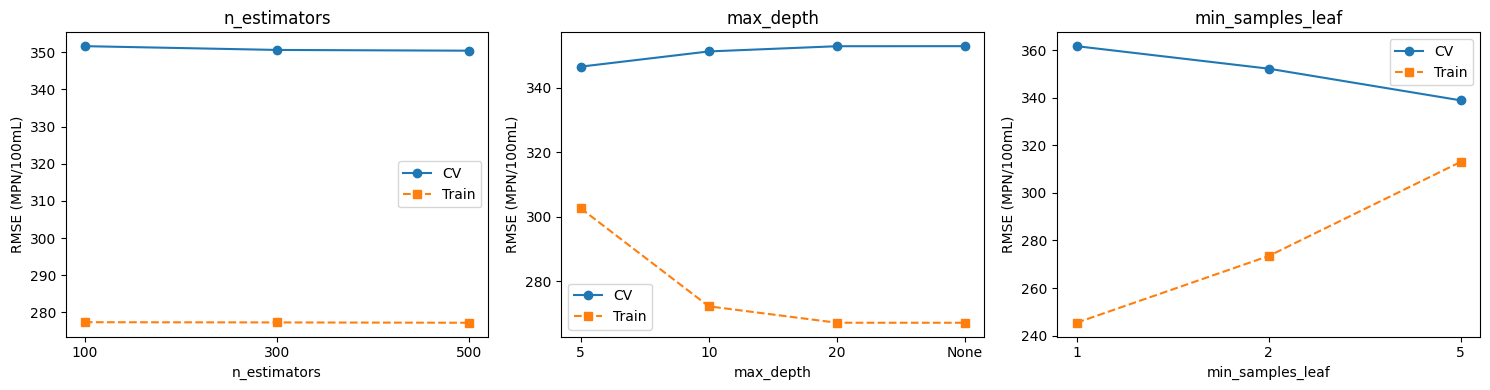

In [11]:
# Pull GridSearchCV results
results = pd.DataFrame(rf_grid.cv_results_)
results['cv_rmse'] = -results['mean_test_score']
results['train_rmse'] = -results['mean_train_score']

# Fill None with string so groupby keeps it
results['param_regressor__model__max_depth'] = (
    results['param_regressor__model__max_depth'].fillna('None')
)

# Plot one subplot per hyperparameter
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, param in zip(axes, ['n_estimators', 'max_depth', 'min_samples_leaf']):
    col = f'param_regressor__model__{param}'
    grouped = results.groupby(col)[['cv_rmse', 'train_rmse']].mean()
    
    ax.plot(grouped.index.astype(str), grouped['cv_rmse'], 'o-', label='CV')
    ax.plot(grouped.index.astype(str), grouped['train_rmse'], 's--', label='Train')
    ax.set_xlabel(param)
    ax.set_ylabel('RMSE (MPN/100mL)')
    ax.set_title(param)
    ax.legend()

plt.tight_layout()
plt.savefig('../figures/13_regression_rf_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations**

The three subplots show how CV RMSE and Train RMSE respond to each hyperparameter, averaged across the other two.

- 'n_estimators': CV RMSE is essentially flat across 100, 300, 500. The number of trees reaches the highest quickly — more trees do not improve validation performance.

- 'max_depth': CV RMSE barely changes while Train RMSE drops as depth increases. The model gains capacity to fit the training set but not to generalise, which is a mild overfitting pattern.

- 'min_samples_leaf': The only hyperparameter with a clear CV trend. CV RMSE drops from about 360 at 'min_samples_leaf=1' to around 340 at 'min_samples_leaf=5', while Train RMSE rises. 
This is regularisation working: larger leaves prevent trees from memorising individual training points.

The selected value 'min_samples_leaf=5' is the largest in the grid, so values like 7 or 10 might give slightly better CV RMSE. The improvement is likely small given the downward trend is already flattening.

## 4.4 MLP Regressor

A Multi-layer Perceptron will be conducted as mentioned in the EDA. It can capture non-linear relationships and feature interactions through hidden layers, but it tend to overfit on small datasets. 

Three key hyperparameters are tuned with 5-fold cross-validation:

- 'hidden_layer_sizes': structure of hidden layers (controls model capacity)
- 'alpha': L2 regularisation strength (controls overfitting)
- 'learning_rate_init': initial learning rate (controls training speed and stability)

In [12]:
# Build pipeline: preprocessing + MLP
mlp_pipe = Pipeline([
    ('pre', preprocessor),
    ('model', MLPRegressor(
        max_iter=1000,
        early_stopping=False,
        random_state=42,
    ))
])
# Wrap with log transformation
mlp_reg = TransformedTargetRegressor(
    regressor=mlp_pipe,
    func=np.log1p,
    inverse_func=np.expm1
)
# Hyperparameter grid
param_grid = {
    'regressor__model__hidden_layer_sizes': [(8,), (16,), (32,), (32, 16)],
    'regressor__model__alpha': [0.01, 0.1, 1, 10],
    'regressor__model__learning_rate_init': [0.001, 0.01],
}
# GridSearchCV
mlp_grid = GridSearchCV(
    mlp_reg,
    param_grid=param_grid,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='neg_root_mean_squared_error',
    n_jobs=-1, # Use all the capacity
    return_train_score=True,
)

mlp_grid.fit(X_train, y_reg_train)

# Best result
mlp_cv_rmse = -mlp_grid.best_score_
mlp_best_params = mlp_grid.best_params_

# Train RMSE
mlp_train_pred = mlp_grid.best_estimator_.predict(X_train)
mlp_train_rmse = root_mean_squared_error(y_reg_train, mlp_train_pred)

print(f"Best params: {mlp_best_params}")
print(f"MLP CV RMSE:    {mlp_cv_rmse:.1f} MPN/100mL")
print(f"MLP Train RMSE: {mlp_train_rmse:.1f} MPN/100mL")

Best params: {'regressor__model__alpha': 10, 'regressor__model__hidden_layer_sizes': (16,), 'regressor__model__learning_rate_init': 0.01}
MLP CV RMSE:    325.9 MPN/100mL
MLP Train RMSE: 323.3 MPN/100mL


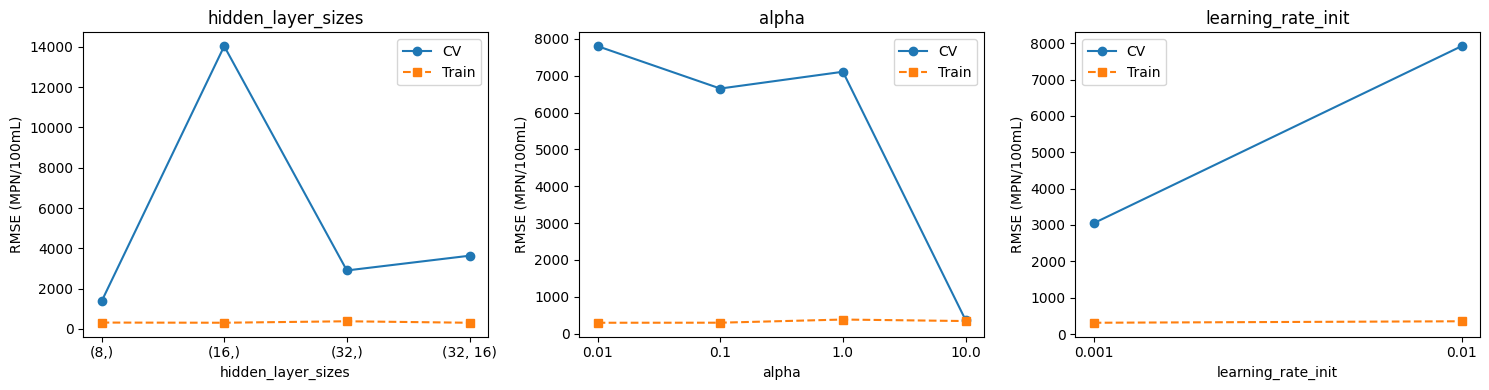

In [13]:
# Pull GridSearchCV results
results = pd.DataFrame(mlp_grid.cv_results_)
results['cv_rmse'] = -results['mean_test_score']
results['train_rmse'] = -results['mean_train_score']

# Plot one subplot per hyperparameter
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, param in zip(axes, ['hidden_layer_sizes', 'alpha', 'learning_rate_init']):
    col = f'param_regressor__model__{param}'
    grouped = results.groupby(col)[['cv_rmse', 'train_rmse']].mean()
    
    ax.plot(grouped.index.astype(str), grouped['cv_rmse'], 'o-', label='CV')
    ax.plot(grouped.index.astype(str), grouped['train_rmse'], 's--', label='Train')
    ax.set_xlabel(param)
    ax.set_ylabel('RMSE (MPN/100mL)')
    ax.set_title(param)
    ax.legend()

plt.tight_layout()
plt.savefig('../figures/14_regression_mlp_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations**

The three subplots show the average CV RMSE and Train RMSE across all configurations at each hyperparameter value. Unlike Random Forest, the MLP curves show large spikes — caused by some configurations where the model fails to converge cleanly.

- 'hidden_layer_sizes': The spikes might come from unstable combinations, not from the network size itself. Train RMSE stays low (around 290) because training still converges; the problem only shows up on validation.

- 'alpha': CV RMSE drops sharply at 'alpha=10', where regularisation is strong enough to keep all combinations stable. The MLP clearly needs very strong regularisation on this dataset.

- 'learning_rate_init': A larger learning rate (0.01) will make it unstable while the regularisation is weak.

The selected configuration ((16,), alpha=10, lr=0.01) sits in the stable region, giving CV RMSE 326 and Train RMSE 323 — a tight gap that shows the model generalises as well as it fits. 

And also find that MLP performance depends heavily on hyperparameter choice on this small dataset, in a way Random 
Forest does not.

## 4.5 Compare and select final regression model

Compare all the four regression models on their 5-fold CV RMSE and Train RMSE to select the model. The selected model will be saved to the 'models/' folder and used in the final evaluation for testing.

        Model  CV RMSE  Train RMSE
        Dummy    381.7         NaN
       Linear    436.2       322.3
Random Forest    338.1       309.7
          MLP    325.9       323.3


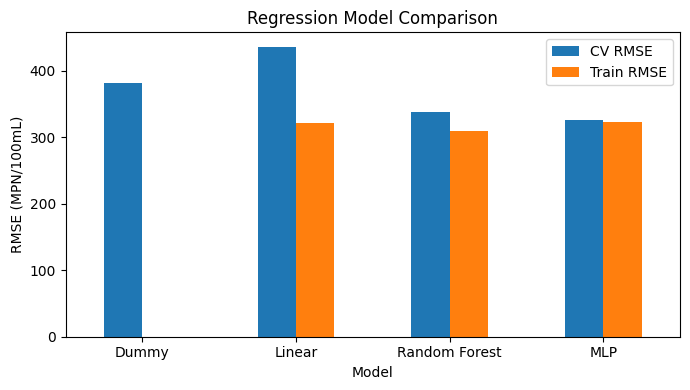

In [14]:
# Collect CV and Train RMSE for all four models
comparison = pd.DataFrame({
    'Model': ['Dummy', 'Linear', 'Random Forest', 'MLP'],
    'CV RMSE': [dummy_cv_rmse, lr_cv_rmse, rf_cv_rmse, mlp_cv_rmse],
    'Train RMSE': [np.nan, lr_train_rmse, rf_train_rmse, mlp_train_rmse],
})

print(comparison.round(1).to_string(index=False))

# Bar chart
comparison.plot(x='Model', y=['CV RMSE', 'Train RMSE'], kind='bar', figsize=(7, 4))
plt.ylabel('RMSE (MPN/100mL)')
plt.title('Regression Model Comparison')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../figures/18_regression_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

**Selection**

Based on the comparison visualisation, several findings and summaries will be presented below:

- Dummy (CV 450): It only predicts the mean and no tuning.

- Linear Regression (CV 436, Train 322): It is barely better than dummy on CV, with a large CV-Train gap showing sensitivity to extreme values. The linear assumption limits performance.

- Random Forest (CV 338, Train 310): It has a 22% CV improvement over Linear, with a small CV-Train gap indicating stable generalisation.

- MLP (CV 326, Train 323): It has the lowest CV RMSE and the tightest Train-CV gap, indicating both strong fit and strong generalisation.

MLP achieves the best CV RMSE (326 vs RF's 338) with the smallest Train-CV gap, showing it generalises better than RF on this dataset once properly regularised ('alpha=10'). The Section 4.4 tuning plots confirmed that the selected MLP configuration sits in a stable region 
of the hyperparameter space.

So MLP is selected as the final regression model.

In [15]:
# Save the model
joblib.dump(mlp_grid.best_estimator_, '../models/1_rg_mdl_regression_mlp.pkl')

['../models/1_rg_mdl_regression_mlp.pkl']

# 5. Classification Modelling

This section builds and tunes four classification models to predict 'ecoli_band' (A–E), alongside a 'DummyClassifier' baseline. Each model is built as a pipeline combining the preprocessor with the classifier. Class imbalance is handled by 'class_weight='balanced'', and 'StratifiedKFold' is used for cross-validation to preserve band proportions in every fold. Models are compared by macro-F1, as justified 
in Section 3. 

## 5.1 Dummy baseline

Establish a 'DummyClassifier' baseline with 'strategy='most_frequent'', which always predicts the majority band.

The dummy is evaluated using 5-fold cross-validation on the training set, with the same metric(macro F1) used to compare the other models.

In [16]:
# Build the dummy 
dummy_clf = DummyClassifier(strategy='most_frequent', random_state=42)

# 5-fold CV
cv_scores = cross_val_score(
    dummy_clf,
    X_train,
    y_clf_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro'
)

dummy_cv_f1 = cv_scores.mean()
dummy_cv_f1_std = cv_scores.std()

print(f"Dummy CV macro-F1: {dummy_cv_f1:.3f} ± {dummy_cv_f1_std:.3f}")

Dummy CV macro-F1: 0.094 ± 0.002


**Observation**

Dummy macro-F1 is just 0.094, which makes sense because the dummy only predicts the majority band D and gives zero F1 on the other four bands.

## 5.2 Logistic Regression

Logistic Regression is the simple baseline for the classification task. It assumes linear boudaries between bands, which might not fit very cleanly (observed in EDA). While this model still being trained to see how it goes.

'class_weight='balanced'' is used to give minority bands B (33) and C (20) the same weight as the majority bands during training. The regularisation strength 'C' is tuned with 5-fold stratified CV.

In [17]:
# Build pipeline: preprocessing + logistic regression
lor_pipe = Pipeline([
    ('pre', preprocessor),
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=2000,
        random_state=42,
    ))
])

# Hyperparameter grid
param_grid = {
    'model__C': [0.01, 0.1, 1.0, 10.0, 100.0],
}

# GridSearchCV with stratified CV
lor_grid = GridSearchCV(
    lor_pipe,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    return_train_score=True,
)

lor_grid.fit(X_train, y_clf_train)

# Best result
lor_cv_f1 = lor_grid.best_score_
lor_best_params = lor_grid.best_params_

# Train F1
lor_train_pred = lor_grid.best_estimator_.predict(X_train)
lor_train_f1 = f1_score(y_clf_train, lor_train_pred, average='macro')

print(f"Best params: {lor_best_params}")
print(f"Logistic Regression CV macro-F1:    {lor_cv_f1:.3f}")
print(f"Logistic Regression Train macro-F1: {lor_train_f1:.3f}")

Best params: {'model__C': 100.0}
Logistic Regression CV macro-F1:    0.378
Logistic Regression Train macro-F1: 0.508


**Observations**

The best regularisation is 'C=100', with CV macro-F1 0.378 and Train macro-F1 0.508. The gap between these two results shows a mild overfitting, which means the model fits the training set a bit better.

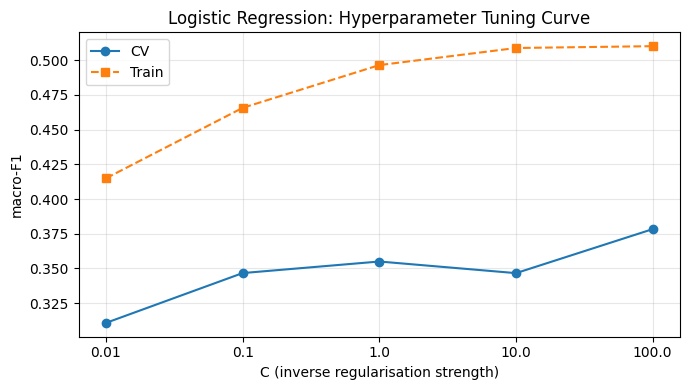

In [18]:
# Pull GridSearchCV results
results = pd.DataFrame(lor_grid.cv_results_)
results['cv_f1'] = results['mean_test_score']
results['train_f1'] = results['mean_train_score']
# Plot CV F1 and Train F1
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(results['param_model__C'].astype(str), results['cv_f1'], 'o-', label='CV')
ax.plot(results['param_model__C'].astype(str), results['train_f1'], 's--', label='Train')
ax.set_xlabel('C (inverse regularisation strength)')
ax.set_ylabel('macro-F1')
ax.set_title('Logistic Regression: Hyperparameter Tuning Curve')
ax.legend()
ax.grid(True, alpha=0.3)
# Save and show
plt.tight_layout()
plt.savefig('../figures/15_classification_logistic_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations**

The tuning curve shows two clear patterns:

Train F1 rises steadily with C, from about 0.42 to 0.51 as the weaker regularisation lets the model fit the training set more closely. And for CV F1, it rises more slowly from around 0.31 to 0.38. And it shows little change from C=0.1 to C=10.

The widening gap between Train and CV confirms the mild overfitting in all configurations. The limited improvement appearing(C=0.1 to C=100) shows the linear decision boundaries. It also reflects EDA finding that band E as extremes are easier compared with band A-D clustered tightly.

## 5.3 Random Forest Classifier

Random Forest Classifier captures non-linear decision boundaries, which the Logistic Regression result in 5.2 suggested that should need to separate the middle bands. The threshold-like signals in EDA that discussed are what tree-based models handle with.

Three key hyperparameters are tuned with 5-fold cross-validation:

- 'n_estimators': number of trees in the forest
- 'max_depth': maximum depth of each tree (controls model capacity)
- 'min_samples_leaf': minimum samples required at a leaf (controls overfitting)

In [19]:
# Build pipeline: preprocessing + random forest classifier
rfc_pipe = Pipeline([
    ('pre', preprocessor),
    ('model', RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
    ))
])
# Hyperparameter grid
param_grid = {
    'model__n_estimators': [100, 300, 500],
    'model__max_depth': [5, 10, 20, None],
    'model__min_samples_leaf': [1, 2, 5, 7],
}

# GridSearchCV with stratified CV
rfc_grid = GridSearchCV(
    rfc_pipe,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1,
    return_train_score=True,
)

rfc_grid.fit(X_train, y_clf_train)

# Best result
rfc_cv_f1 = rfc_grid.best_score_
rfc_best_params = rfc_grid.best_params_

# Train F1
rfc_train_pred = rfc_grid.best_estimator_.predict(X_train)
rfc_train_f1 = f1_score(y_clf_train, rfc_train_pred, average='macro')

print(f"Best params: {rfc_best_params}")
print(f"Random Forest CV macro-F1:    {rfc_cv_f1:.3f}")
print(f"Random Forest Train macro-F1: {rfc_train_f1:.3f}")

Best params: {'model__max_depth': 10, 'model__min_samples_leaf': 5, 'model__n_estimators': 100}
Random Forest CV macro-F1:    0.454
Random Forest Train macro-F1: 0.666


**Observations**

The best configuration is 'max_depth=10', 'min_samples_leaf=5', and 'n_estimators=100'. CV macro-F1 is 0.454, which shows a 20% improvement over Logistic Regression(0.378). This confirms that tree-based model fits better for such a threshold-like pattern.

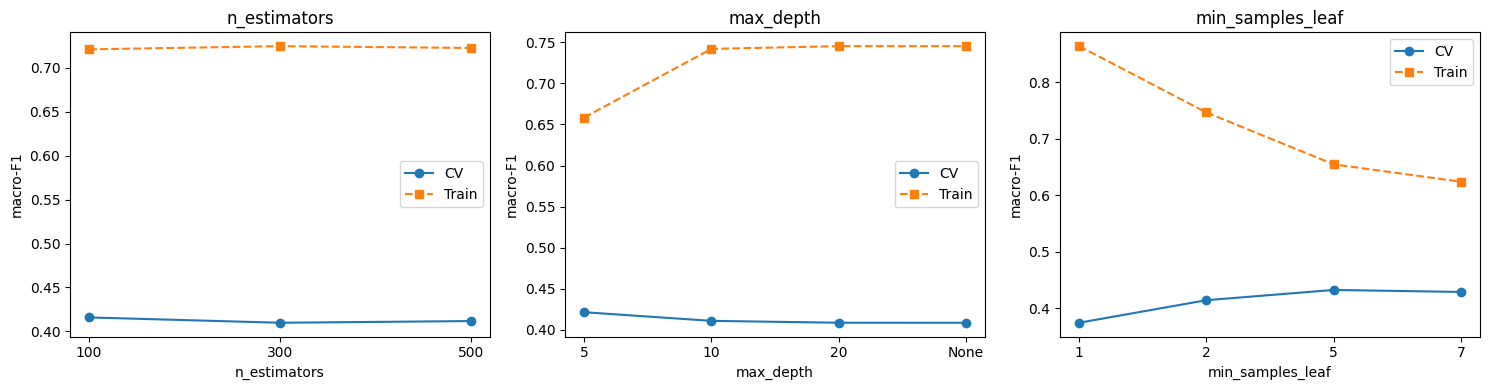

In [20]:
# Pull GridSearchCV results
results = pd.DataFrame(rfc_grid.cv_results_)
results['cv_f1'] = results['mean_test_score']
results['train_f1'] = results['mean_train_score']

# Fill None with string so groupby keeps it
results['param_model__max_depth'] = results['param_model__max_depth'].fillna('None')

# Plot one subplot per hyperparameter
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, param in zip(axes, ['n_estimators', 'max_depth', 'min_samples_leaf']):
    col = f'param_model__{param}'
    grouped = results.groupby(col)[['cv_f1', 'train_f1']].mean()
    
    ax.plot(grouped.index.astype(str), grouped['cv_f1'], 'o-', label='CV')
    ax.plot(grouped.index.astype(str), grouped['train_f1'], 's--', label='Train')
    ax.set_xlabel(param)
    ax.set_ylabel('macro-F1')
    ax.set_title(param)
    ax.legend()

plt.tight_layout()
plt.savefig('../figures/16_classification_rf_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations**

The three subplots show CV F1 and Train F1 averaged across the other two hyperparameters.

- 'n_estimators': Flat at around 0.42 for both CV and Train. And it reaches the plateau and keeps still.

- 'max_depth': CV F1 peaks at around 0.42 with 'max_depth=5' and drops slightly when trees grow deeper. Train F1 jumps from about 0.66 at depth 5 to about 0.74 from depth 10 onward, showing deeper trees fit the training set better but do not generalise.

- 'min_samples_leaf': The only hyperparameter with a clear CV 
trend. CV F1 rises from around 0.37 at 'leaf=1' to 0.43 at 'leaf=5', then dips slightly at 'leaf=7'. This confirms 'leaf=5' should be the optimal point. And going further increasing leaf size starts to lose CV performance.

The gap between CV and Train is wider (0.45 & 0.66), which indicates that this model needs stronger regularisation. While the selected 'min_samples_leaf=5' sits at the upper edge of the grid. It indicates that the overfitting is structural driven by the small per-class size rather than tuning.

## 5.4 MLP Classifier

A Multi-layer Perceptron will be conducted in this section. It can capture non-linear relationships and feature interactions through hidden layers, but it tend to overfit on small datasets. 

Three key hyperparameters are tuned with 5-fold cross-validation:

- 'hidden_layer_sizes': structure of hidden layers (controls model capacity)
- 'alpha': L2 regularisation strength (controls overfitting)
- 'learning_rate_init': initial learning rate (controls training speed and stability)

In [21]:
# Build pipeline: preprocessing + MLP classifier
mlpc_pipe = Pipeline([
    ('pre', preprocessor),
    ('model', MLPClassifier(
        max_iter=1000,
        early_stopping=False,
        random_state=42,
    ))
])

# Hyperparameter grid
param_grid = {
    'model__hidden_layer_sizes': [(8,), (16,), (32,), (32, 16)],
    'model__alpha': [0.01, 0.1, 1.0, 10.0],
    'model__learning_rate_init': [0.001, 0.01],
}

# GridSearchCV with stratified CV
mlpc_grid = GridSearchCV(
    mlpc_pipe,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1,
    return_train_score=True,
)

mlpc_grid.fit(X_train, y_clf_train)

# Best result
mlpc_cv_f1 = mlpc_grid.best_score_
mlpc_best_params = mlpc_grid.best_params_

# Train F1
mlpc_train_pred = mlpc_grid.best_estimator_.predict(X_train)
mlpc_train_f1 = f1_score(y_clf_train, mlpc_train_pred, average='macro')

print(f"Best params: {mlpc_best_params}")
print(f"MLP CV macro-F1:    {mlpc_cv_f1:.3f}")
print(f"MLP Train macro-F1: {mlpc_train_f1:.3f}")

Best params: {'model__alpha': 0.01, 'model__hidden_layer_sizes': (16,), 'model__learning_rate_init': 0.01}
MLP CV macro-F1:    0.383
MLP Train macro-F1: 0.668


**Observations**

The best configuration is 'hidden_layer_sizes=(16,)', 'alpha=0.01', 'learning_rate_init=0.01'. CV macro-F1 is 0.383 — a bit higher than Logistic Regression (0.378) but well below Random Forest (0.454).

The Train-CV gap is 0.285, the widest of the three trained models, showing the MLP overfits the most. While the selected 'alpha=0.01' is the weakest regularisation in the grid: stronger regularisation reduces CV F1 because it blurs the decision boundaries between neighbouring bands, especially the minority bands B and C. 

This points to a structural limit: 'MLPClassifier' does not support 'class_weight', so the model cannot give extra attention to bands B and C the way Logistic Regression and Random Forest can. 
With only 16 samples in band C and 26 in band B, weaker regularisation only helps the model memorise the training set rather than learn these classes.

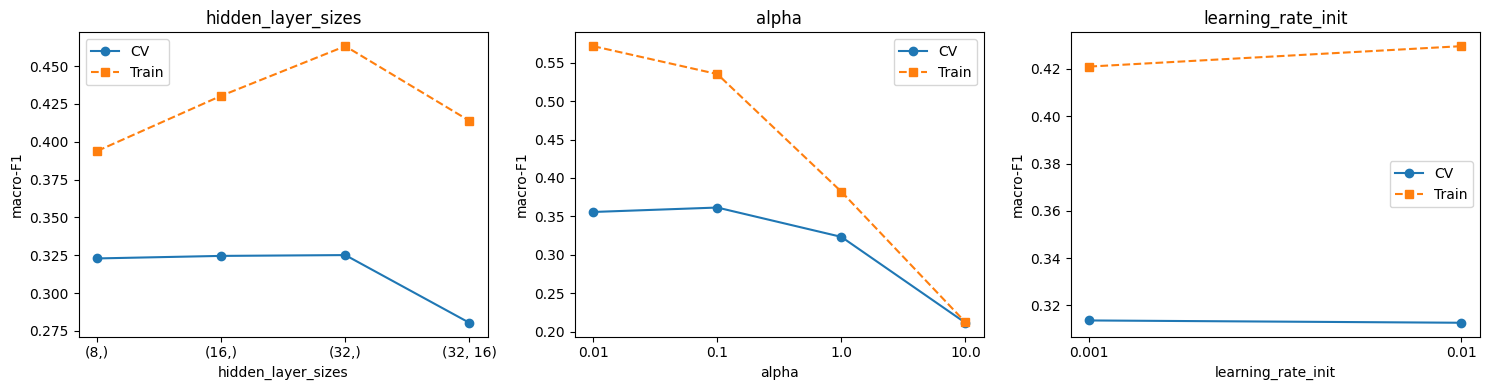

In [22]:
# Pull GridSearchCV results
results = pd.DataFrame(mlpc_grid.cv_results_)
results['cv_f1'] = results['mean_test_score']
results['train_f1'] = results['mean_train_score']

# Plot one subplot per hyperparameter
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, param in zip(axes, ['hidden_layer_sizes', 'alpha', 'learning_rate_init']):
    col = f'param_model__{param}'
    grouped = results.groupby(col)[['cv_f1', 'train_f1']].mean()
    
    ax.plot(grouped.index.astype(str), grouped['cv_f1'], 'o-', label='CV')
    ax.plot(grouped.index.astype(str), grouped['train_f1'], 's--', label='Train')
    ax.set_xlabel(param)
    ax.set_ylabel('macro-F1')
    ax.set_title(param)
    ax.legend()

plt.tight_layout()
plt.savefig('../figures/17_classification_mlp_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations**

The three subplots show CV F1 and Train F1 averaged across the other two hyperparameters.

- 'hidden_layer_sizes': CV F1 is flat around 0.32 across (8,), (16,), (32,), then drops to 0.28 at (32, 16). Train F1 follows the same pattern. Adding capacity does not help a lot small as networks already use what the data offers.

- 'alpha': Both CV and Train F1 drop sharply once alpha goes above 1.0 and combines at the number of about 0.2 at alpha=10. So strong regularisation here offers limited help to this model and MLP needs weak regularisation to maintain enough flexibility here.

- 'learning_rate_init': No noticeable patterns are observed. CV F1 is identical at 0.001 and 0.01.

Thus, without 'class_weight' support, this MLP model cannot properly learn the minority bands B and C.

## 5.5 Compare and select the final classification model

Compare all the four classification models on their 5-fold strtified CV macro-F1 and Train macro-F1 to select the model. The selected model will be saved to the 'models/' folder and used in the final evaluation for testing.

        Model  CV F1  Train F1
        Dummy  0.094       NaN
     Logistic  0.378     0.508
Random Forest  0.454     0.666
          MLP  0.383     0.668


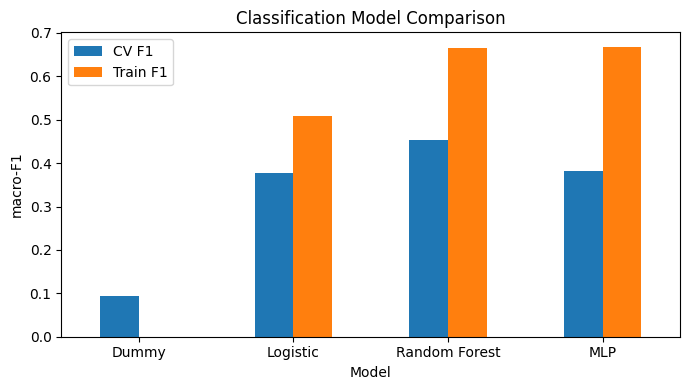

In [23]:
# Collect CV and Train F1 for all four models
comparison = pd.DataFrame({
    'Model': ['Dummy', 'Logistic', 'Random Forest', 'MLP'],
    'CV F1': [dummy_cv_f1, lor_cv_f1, rfc_cv_f1, mlpc_cv_f1],
    'Train F1': [np.nan, lor_train_f1, rfc_train_f1, mlpc_train_f1],
})

print(comparison.round(3).to_string(index=False))

# Bar chart
comparison.plot(x='Model', y=['CV F1', 'Train F1'], kind='bar', figsize=(7, 4))
plt.ylabel('macro-F1')
plt.title('Classification Model Comparison')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../figures/19_classification_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

**Selection**

Based on the comparison visualisation, several findings and summaries will be presented below:

- Dummy (CV 0.094): It only predicts the majority band and give zero F1 on the other four.

- Logistic Regression (CV 0.38, Train 0.51): It captures linear signal in the data, four times better than dummy. Meanwhile it is imited by its linear assumption.

- Random Forest (CV 0.45, Train 0.67): It is clearly the strongest model. Non-linear decision boundaries and 'class_weight' support let it handle the threshold-like signals and the class imbalance.

- MLP (CV 0.38, Train 0.67): The lack of 'class_weight' support and the small per-class sample size prevent the MLP's flexibility from translating into better performance.

Thus, Random Forest is the clear winner on CV macro-F1 (0.45 vs 0.38 for the other two trained models). It also offers interpretability through feature importance and supports 'class_weight' for handling the imbalance directly. 

So Random Forest is selected as the final classification model

In [24]:
# Save the final classification model
joblib.dump(rfc_grid.best_estimator_, '../models/2_cf_mdl_classification_random_forest.pkl')

['../models/2_cf_mdl_classification_random_forest.pkl']

# 6. Final Evaluation

Evaluate the two final models: MLP for regression and Random Forest for classification on the test set. The results will reflect how models would perform on new data.

For each task, performance is reported using metrics selected in Section 3 as well as the visualisations. And performance then will be broken down by region, land cover type and altitude to identify where the models are reliable and where not. 

## 6.1 Regression Evaluation

The final MLP regression model will be evaluated on the test set. And performance is reported using RMSE, MAE, and R² on the original MPN/100mL scale, followed by a breakdown by region, land cover type, and altitude. 

In [25]:
# Load the final regression model
final_reg = mlp_grid.best_estimator_

# Predict on the test set
y_reg_pred = final_reg.predict(X_test)

# Overall metrics
test_rmse = root_mean_squared_error(y_reg_test, y_reg_pred)
test_mae = mean_absolute_error(y_reg_test, y_reg_pred)
test_r2 = r2_score(y_reg_test, y_reg_pred)

print(f"Test RMSE: {test_rmse:.1f} MPN/100mL")
print(f"Test MAE:  {test_mae:.1f} MPN/100mL")
print(f"Test R²:   {test_r2:.3f}")

Test RMSE: 366.3 MPN/100mL
Test MAE:  179.6 MPN/100mL
Test R²:   0.242


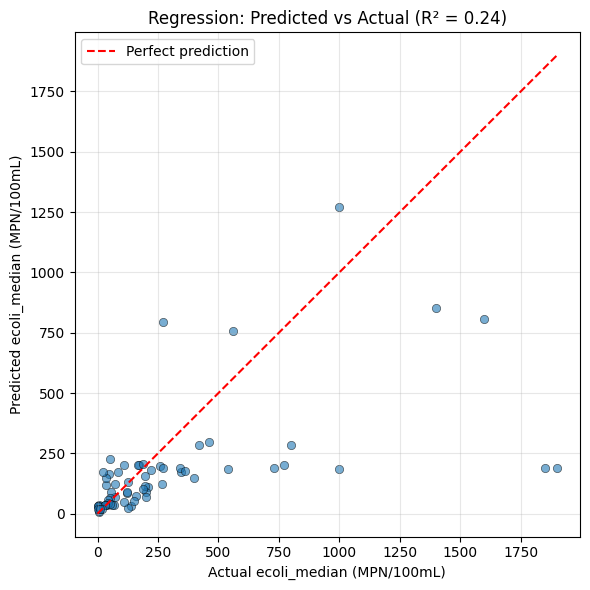

In [26]:
# Predicted vs actual scatter plot
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(y_reg_test, y_reg_pred, alpha=0.6, edgecolors='k', linewidth=0.5)

# Perfect prediction line
max_val = max(y_reg_test.max(), y_reg_pred.max())
ax.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction')

ax.set_xlabel('Actual ecoli_median (MPN/100mL)')
ax.set_ylabel('Predicted ecoli_median (MPN/100mL)')
ax.set_title(f'Regression: Predicted vs Actual (R² = {test_r2:.2f})')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/20_regression_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations**

The metrics and scatter plot shows the following patterns:

- 1. For low-to-mid range(0-300 MPN/100ml): predictions cluster around the perfect line, which indicates that the model is reliable for clean and moderate contaminated sites.

- 2. For high range(>500 MPN/100ml): the model obviously underpredicts. Several site with actual values that over 500 are predicted at around 250. And the most contaminated sites are not recognised by the model.

- 3. The R² OF 0.24 confirms that catchment features explain only a limited share of variation in 'ecoli_median'.

*Break down test set performance by region, land cover type, and altitude to identify where the regression model is reliable and where it is not.*

In [27]:
# Build results table: features + actual + predicted + region (region was 
# excluded from the model, so attach it back from df for subgroup grouping).
reg_results = X_test.copy()
reg_results['actual'] = y_reg_test.values
reg_results['predicted'] = y_reg_pred
reg_results['region'] = df.loc[X_test.index, 'region'].values

# RMSE by region
print("=== By region ===")
for group, sub in reg_results.groupby('region'):
    rmse = root_mean_squared_error(sub['actual'], sub['predicted'])
    print(f"{group:20s}  n={len(sub):2d}  RMSE={rmse:.1f}")

# RMSE by land cover type
print("\n=== By rec_land_cover_type ===")
for group, sub in reg_results.groupby('rec_land_cover_type'):
    rmse = root_mean_squared_error(sub['actual'], sub['predicted'])
    print(f"{group:20s}  n={len(sub):2d}  RMSE={rmse:.1f}")

# RMSE by altitude
print("\n=== By wfs_altitude ===")
for group, sub in reg_results.groupby('wfs_altitude'):
    rmse = root_mean_squared_error(sub['actual'], sub['predicted'])
    print(f"{group:20s}  n={len(sub):2d}  RMSE={rmse:.1f}")

=== By region ===
Auckland              n= 9  RMSE=227.9
Gisborne              n= 6  RMSE=75.3
Hawke'S Bay           n= 2  RMSE=87.4
Manawatū-Whanganui    n= 6  RMSE=78.4
Otago                 n=18  RMSE=146.3
Southland             n= 1  RMSE=250.4
Taranaki              n= 4  RMSE=89.0
Tasman                n= 1  RMSE=541.1
Waikato               n=15  RMSE=675.4
Wellington            n= 2  RMSE=681.5
West Coast            n= 4  RMSE=82.4

=== By rec_land_cover_type ===
Native vegetation     n=20  RMSE=40.7
Pasture               n=42  RMSE=430.4
Urban                 n= 6  RMSE=467.4

=== By wfs_altitude ===
lowland               n=38  RMSE=486.7
upland                n=30  RMSE=64.0


**Observations**

The subgroup result shows a strong pattern: the regression model's performace depends almost on whether the site is in a human-modified or natural catchment.

- Land cover: this is the most discriminating one. RMSE on Native vegetation sites is only 40.7, while rises up 10 times higher when it comes to Pasture and Urban.

- Altitude: it shows the similar pattern.(upland RMSE 64 and lowland 487), which is related to land cover since most upland sites are Native vegetation and most lowland sites are Pasture or Urban.

- Region: Waikato (n=15, dominated by intensive 
pastoral land use) has the highest reliable RMSE at 675 while regions with more native or upland sites (Gisborne, West Coast, Taranaki) all show RMSE below 100. Tasman and Wellington show very high RMSE but have only 1–2 test sites each, so these are unreliable.

The pattern is consistent with the finding mentioned in EDA 4.2.1. The model can reliably confirm a clean site but cannot reliably quantify how contaminated a non-clean site is.

## 6.2 Classification Evaluation

The final Random Forest classification model will be evaluated on the test set. And performance is reported using macro-F1, accuracy, per-class precision/recall/F1, and the confusion matrix, followed by a breakdown by region, land cover type, and altitude. 

In [28]:
# Load the final classification model
final_clf = rfc_grid.best_estimator_

# Predict on the test set
y_clf_pred = final_clf.predict(X_test)

# Overall metrics
test_accuracy = accuracy_score(y_clf_test, y_clf_pred)
test_macro_f1 = f1_score(y_clf_test, y_clf_pred, average='macro')

print(f"Test accuracy:  {test_accuracy:.3f}")
print(f"Test macro-F1:  {test_macro_f1:.3f}")
print()
print("Per-class breakdown:")
print(classification_report(y_clf_test, y_clf_pred, zero_division=0))

Test accuracy:  0.632
Test macro-F1:  0.526

Per-class breakdown:
              precision    recall  f1-score   support

           A       0.67      0.75      0.71        16
           B       0.25      0.29      0.27         7
           C       0.33      0.25      0.29         4
           D       0.77      0.48      0.59        21
           E       0.69      0.90      0.78        20

    accuracy                           0.63        68
   macro avg       0.54      0.53      0.53        68
weighted avg       0.64      0.63      0.62        68



**The confusion metrix will be shown below for analysis**

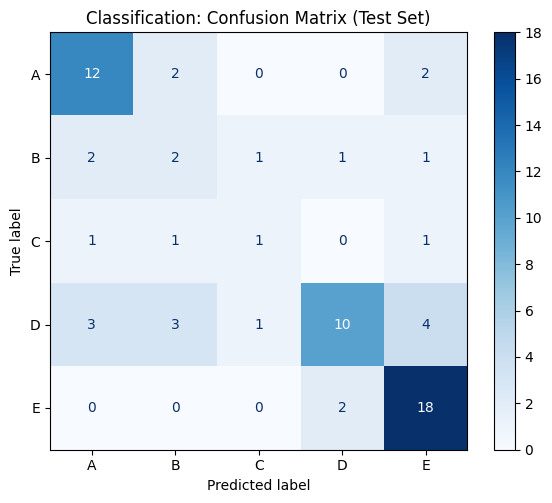

In [29]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_clf_test, y_clf_pred,
    labels=['A', 'B', 'C', 'D', 'E'],
    cmap='Blues',
    ax=ax,
)
ax.set_title('Classification: Confusion Matrix (Test Set)')

plt.tight_layout()
plt.savefig('../figures/21_classification_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

*Observation and analysis on the breakdown table and confusion matrix.*

The classifier reaches accuracy 0.632 and macro-F1 0.526 on the test set. Macro-F1 is slightly higher than the cross-validation score (0.45 in Section 5.5) but should not be over-interpreted given the small test set.

And the confusion matrix show the below patterns:

- 1. Band E recall is 0.90 (18/20 correct), band A recall is 0.75 (12/16). Their feature signatures are clear, and the extremes seem reliable.

- 2. When band E is misclassified, it errs only into D — never into A, B, or C. The model does not confuse severely contaminated sites with clean ones, which matters for management decisions.

- 3. Middle bands are unreliable. Band D recall is 0.48 (11/21 misclassified, scattered across all other bands). Bands B and C have too few test sites (7 and 4) but recalls of 0.29 and 0.25 confirm the model cannot separate them well.

For freshwater management, the model is best suited to screening sites as "likely clean" or "likely severely contaminated", and should not be used to assign a specific NPS-FM band in the middle range.

*Break down test set performance by region, land cover type, and altitude to identify where the regression model is reliable and where it is not.*

In [30]:
# Build results table: features + actual + predicted + region
clf_results = X_test.copy()
clf_results['actual'] = y_clf_test.values
clf_results['predicted'] = y_clf_pred
clf_results['region'] = df.loc[X_test.index, 'region'].values

# Accuracy by region
print("=== By region ===")
for group, sub in clf_results.groupby('region'):
    acc = accuracy_score(sub['actual'], sub['predicted'])
    print(f"{group:20s}  n={len(sub):2d}  accuracy={acc:.3f}")

# Accuracy by land cover type
print("\n=== By rec_land_cover_type ===")
for group, sub in clf_results.groupby('rec_land_cover_type'):
    acc = accuracy_score(sub['actual'], sub['predicted'])
    print(f"{group:20s}  n={len(sub):2d}  accuracy={acc:.3f}")

# Accuracy by altitude
print("\n=== By wfs_altitude ===")
for group, sub in clf_results.groupby('wfs_altitude'):
    acc = accuracy_score(sub['actual'], sub['predicted'])
    print(f"{group:20s}  n={len(sub):2d}  accuracy={acc:.3f}")

=== By region ===
Auckland              n= 9  accuracy=0.778
Gisborne              n= 6  accuracy=0.667
Hawke'S Bay           n= 2  accuracy=1.000
Manawatū-Whanganui    n= 6  accuracy=0.500
Otago                 n=18  accuracy=0.444
Southland             n= 1  accuracy=0.000
Taranaki              n= 4  accuracy=0.750
Tasman                n= 1  accuracy=1.000
Waikato               n=15  accuracy=0.667
Wellington            n= 2  accuracy=1.000
West Coast            n= 4  accuracy=0.750

=== By rec_land_cover_type ===
Native vegetation     n=20  accuracy=0.550
Pasture               n=42  accuracy=0.643
Urban                 n= 6  accuracy=0.833

=== By wfs_altitude ===
lowland               n=38  accuracy=0.658
upland                n=30  accuracy=0.600


**Observations**

The classification subgroup analysis shows a different pattern from the regression subgroup.

- By land cover: Accuracy is highest on Urban sites (0.83), then  Pasture (0.64), then Native vegetation (0.55). This is the opposite of the regression result, where Native sites had the lowest RMSE. The reason is that Urban sites are almost entirely band E, which the classifier identifies very well (recall 0.90), whereas band A sites are harder to lock onto because feature separation between A and the neighbouring bands is less sharp.

- By altitude: Accuracy is similar across lowland (0.66) and upland (0.60). Again opposite to the regression result, where upland was far easier (RMSE 64 vs 487).

- By region: Auckland (0.78) and Waikato (0.67) perform reasonably well. Otago (n=18, accuracy 0.44) is the weakest large region. Single-site regions (Southland, Tasman, Wellington) are not interpretable on so few samples.

This contrast does not mean one task is doing better than the other — it reflects how each metric works. Regression RMSE is naturally small when the true values are small, so Native vegetation sites (mostly clean) look easy. Classification accuracy is naturally high when one band dominates the subgroup, so Urban sites (almost all band E) look easy. The two views together show that regression appears reliable on 
clean sites because their numbers are small, while classification appears reliable on contaminated sites because they fall into a band the model recognises clearly.

## 6.3 Mispredictions Identification and Model Comparisons

In this section, sites that regression and classification failed will be identified respectively, and to find out what those sites are in common. Sites the model 
cannot predict reliably are the strongest signal of where catchment-level features are insufficient.

**Combine all the test sites into a big table for error identification and analysis**

In [31]:
combined = X_test[['rec_land_cover_type', 'wfs_altitude']].copy()
combined['region'] = df.loc[X_test.index, 'region'].values
combined['actual_median'] = y_reg_test.values
combined['predicted_median'] = y_reg_pred.round(0)
combined['abs_error'] = (combined['actual_median'] - combined['predicted_median']).abs()
combined['actual_band'] = y_clf_test.values
combined['predicted_band'] = y_clf_pred

For regression errors, pick the first 10 biggest errors. For classification errors, pick them all out for analysis.

In [32]:
# Top 10 regression errors
print("=== Top 10 regression errors ===")
print(combined.nlargest(10, 'abs_error')[
    ['region', 'rec_land_cover_type', 'wfs_altitude',
     'actual_median', 'predicted_median', 'actual_band', 'predicted_band']
].to_string())

# All classification errors
n_clf_wrong = (combined['actual_band'] != combined['predicted_band']).sum()
print(f"\n=== All classification errors ({n_clf_wrong} sites) ===")
print(combined[combined['actual_band'] != combined['predicted_band']][
    ['region', 'rec_land_cover_type', 'wfs_altitude',
     'actual_median', 'predicted_median', 'actual_band', 'predicted_band']
].to_string())

=== Top 10 regression errors ===
         region rec_land_cover_type wfs_altitude  actual_median  predicted_median actual_band predicted_band
49      Waikato             Pasture      lowland         1900.0             187.0           E              E
35      Waikato             Pasture      lowland         1850.0             187.0           E              E
52      Waikato             Pasture      lowland         1000.0             186.0           E              E
117  Wellington               Urban      lowland         1600.0             807.0           E              E
278       Otago             Pasture      lowland          770.0             202.0           E              D
114  Wellington               Urban      lowland         1400.0             852.0           E              E
301      Tasman             Pasture      lowland          730.0             189.0           E              E
1      Auckland               Urban      lowland          270.0             794.0           E  

Find the error that show up iin both models.

In [33]:
# Sites both models got wrong (regression error > 300 AND band wrong)
both_wrong = combined[(combined['abs_error'] > 300) & 
                      (combined['actual_band'] != combined['predicted_band'])]
print(f"=== Sites both models got wrong: {len(both_wrong)} ===")
print(both_wrong[
    ['region', 'rec_land_cover_type', 'wfs_altitude',
     'actual_median', 'predicted_median', 'actual_band', 'predicted_band']
].to_string())

=== Sites both models got wrong: 1 ===
    region rec_land_cover_type wfs_altitude  actual_median  predicted_median actual_band predicted_band
278  Otago             Pasture      lowland          770.0             202.0           E              D


The findings are as follows:

**Regression Model**

- 1. Among top 10 errors in the regression model, 9 of 10 are Pasture or Urban sites on lowland with very high actual 'ecoli_median' (540–1900 MPN/100mL) but predicted around 200. 4 of these are in Waikato. The regression model under-predicts high-
contamination lowland pastoral sites. The squared loss in RMSE training might discourage the model from predicting extreme values, so it stays near the centre even when the features suggest a contaminated site.

- 2. Interestingly, 9 of these same 10 sites were classified correctly as band E. The classifier recognises them as severely contaminated while the regression model does not commit to the magnitude. 

**Classification Model**

- 1. 25 errors are mostly between neighbouring bands. No band E site is misclassified as A, B, or C, and no band A site is misclassified as D or E except in two earlier cases noted in the confusion matrix. Errors concentrate in the middle range, particularly band D being misclassified into A (2), B (3), C (1), or E (4). Otago pastoral upland sites appear frequently in this error set.

- Both models fail on only 1 site. This very small overlap shows the two models have largely complementary failure modes: regression fails on high-contamination sites while still placing them in roughly the right band, and classification fails between adjacent bands without large numeric errors.

# 7. Findings and Interpretation

Based on the modelling and evaluation results, this section answers the five questions set by the assignment. Each answer will be based on the evidence from previous findings or results.

## 7.1 Regression vs classification: which is more reliable / useful?

1. The two models are reliable on different kinds of sites. The regression MLP reached R² 0.24 on the test set, meaning it explains only about a quarter of the variation in E. coli levels. It works well on clean sites (Native vegetation RMSE 40) but consistently under-predicts contaminated ones. Many sites with true values above 1500 MPN/100mL were predicted at around 200. 
The classifier reached accuracy 0.63 and macro-F1 0.53. It recognises the two extremes very well (recall 0.75 for band A, 0.90 for band E) but struggles with the middle bands B, C, and D. Importantly, it never confuses band E with A, B, or C — when it gets E wrong, it errs into the neighbouring band D.

2. Under NPS-FM 2020, councils make decisions based on the band, not the exact median value. The classifier outputs the band directly, and does fairly reliably for the band that matters most for intervention (band E). 
The regression, by contrast, would mis-assign almost all high-contamination sites: in Section 6.3, 9 of the 10 worst regression errors were sites the classifier correctly identified as band E but the regression placed in band B or C. A council using the regression to decide whether a site needs attention would miss most of the severely contaminated sites.

In a word, The classifier is the more useful tool for NPS-FM 2020 decisions. The regression still has value as a supporting output for clean and moderately contaminated sites, where its continuous estimate adds detail. But it should not be used on its own to decide whether a site is meeting water quality standards.

## 7.2 How should councils responsibly interpret and act on the predictions?

If a regional council were to use the classifier to support NPS-FM 2020 decisions, it could be treated as a useful screening tool but not as a substitute for direct monitoring. 

1. Trust band E and band A predictions. The model correctly identified 90% of true band E sites and 75% of true band A sites. It never predicted band E for a site that was actually A, B, or C. So a site flagged as band E by the model can reasonably be treated as a candidate for intervention, and a site flagged as band A can be treated as low priority for monitoring resources.

2. Be careful with the middle bands(B, C, D). The model's recall on these bands was only 0.29, 0.25, and 0.48. Band D in particular got misclassified into every other band. A site predicted as band C, for example, was only band C about a quarter of the time. Any decision that depends on telling B, C, and D apart should not rest on the model alone.

3. The regression R² of 0.24 means catchment features explain only about a quarter of why E. coli levels differ across sites. The other three-quarters comes from things the model never sees — rainfall events, seasons, farm practices,point-source pollution. 

Use the model to decide where to send the monitoring team first, not to decide whether monitoring is needed at all. Band E predictions deserve attention; band A predictions can be deprioritised; everything in the middle should be confirmed by sampling.

## 7.3 Would the models be reliable on Canterbury?

Canterbury is dominated by intensive pastoral farming on lowland plains with relatively low rainfall, which is similar with a combination that matches the exact profile where both models performed worst in the test evaluation. The expected reliability on Canterbury data should be low.

1. Regression analysis. Subgroup analysis in Section 6.1 showed the regression RMSE on Pasture sites was 430, on Urban sites 467, and on lowland sites overall 487, compared to 40 on Native vegetation and 64 on upland. 
Waikato, which has similar characteristics, had the worst regional RMSE at 675. Canterbury would fall into the same set of "difficult" sites the model already finds hard with.

2. Classification analysis. The classifier is slightly better: lowland accuracy was 0.66, Pasture accuracy 0.64. But Otago (n=18), the largest region in the test set with intensive pastoral sites, achieved only 0.44. This suggests the model's reliability on pastoral-dominated regions is uneven even within the 12 regions, and Canterbury could fall at the lower end.

3. The training data was already uneven for pastoral regions: 33 of the 57 sites dropped due to missing targets came from Hawke's Bay. Even before considering Canterbury, the dataset under-represented some of the regions most similar to it.

In conclusion, The models should not be deployed on Canterbury without further validation. The classifier may produce useful band-E flags for the worst sites, but middle-band predictions and any regression-derived medians should be treated as preliminary estimates only.

## 7.4 Trade-offs of a binary "pass / fail" classification

1. **Advantages**
The biggest gain is reliability. The current model struggles most with telling neighbouring bands apart (recalls of 0.29, 
0.25, and 0.48 for bands B, C, and D in Section 6.2). A binary helps to figure out these confusions: a B-vs-C error or a C-vs-D error no longer matters because both are on the same side of the threshold. The training data also becomes less imbalanced (114 "pass" vs 225 "fail" in this dataset, compared to 16 to 104 across the five bands). The model should almost certainly achieve higher overall accuracy and recall on the "fail" group.

The output would also be easier for councils to act on: "this site needs attention, yes or no" is a clearer signal than a five-level classification, especially when the middle levels are unreliable.

2. **Disadvantages**
The biggest loss is the priorities. Under NPS-FM 2020, band C, band D, and band E describe very different levels of contamination: band C sites need monitoring and gradual improvement, band D sites need active management, and band E sites require immediate intervention. A binary "fail" label gives a council no way to tell these apart, so it loses the prioritisation.

A binary model would be more accurate and efficient but less useful for the actual decisions. The reliable band E identification in the current five-band model is the most valuable piece of information for intervention decisions, and it would be folded into a generic "fail" label in the binary version. 

## 7.5 What would I do differently or additionally next time?

1. Collect more data on under-represented bands. Band C had only 16 training rows, and the model could not learn it reliably (recall 0.25). Targeted sampling at sites expected to fall in band B or C would balance the dataset and improve the middle-band predictions that are currently the weakest part of the model.

2. Use an ordinal classifier instead of a multiclass one. The current classifier treats bands A, B, C, D, E as five unrelated labels, so an A→E error is penalised the same as an A→B error. But the bands are ordered, and the misclassifications I saw in Section 6.2 (band D scattered across A, B, C, and E) might cluster closer to the true band under an ordinal model. This is the change likely to improve the middle-band recalls without needing more data.

3. Try a regression loss that does not punish extreme predictions. The regression MLP was trained on RMSE, which penalises large errors quadratically and therefore pushes the model to predict near the centre. This is why Section 6.3 showed nine band-E sites predicted at around 200 MPN. Next time I would try quantile loss, log-cosh, or Huber loss — all of which let the model commit to high values without catastrophic risk if it is wrong.

4. Choose Random Forest as a compartison with MLP for stability. I picked MLP for regression in Section 4.5 because its CV RMSE was 12 MPN better than RF. But the MLP only worked at alpha=10 — other configurations produced extreme predictions. RF was stable across the entire hyperparameter grid. With hindsight the 12 MPN advantage was not worth the deployment risk; I would pick RF next time.